In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from sklearn.preprocessing import StandardScaler



In [8]:
df= pd.read_csv("thyroid_dataset.csv")

In [9]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [10]:
df.shape

(6916, 22)

In [11]:
X = df.drop("Outlier_label",axis=1)


In [12]:
scaler = StandardScaler()

In [13]:
x_scaled = scaler.fit_transform(X)

In [14]:
x_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

isolation forest for anomaly detection

In [15]:
from sklearn.ensemble import IsolationForest

In [16]:
clf = IsolationForest(
    n_estimators=100,
     contamination="auto",
    random_state=42
)

In [17]:
labels = clf.fit_predict(x_scaled)

In [18]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

x_pca = pca.fit_transform(x_scaled)

Text(0, 0.5, 'pc2')

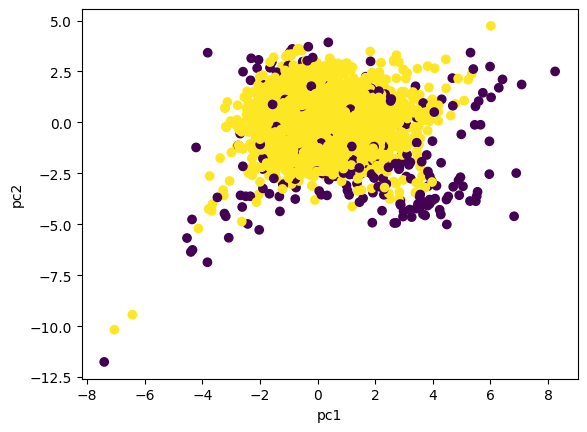

In [20]:
plt.Figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)
plt.xlabel("pc1")
plt.ylabel("pc2")

In [22]:
n_outliers = np.sum(labels==-1)
n_normal= np.sum(labels==1)
print(n_outliers)
print(n_normal)

275
6641
